---
Phase 6-3: 模型部署 — 從實驗室到生產環境
---

模型訓練好了，量化加速也做了，怎麼讓別人用？

本檔涵蓋：
  1. 知識蒸餾 (Knowledge Distillation)
  2. 模型剪枝 (Pruning)
  3. FastAPI 部署
  4. Docker 容器化
  5. 完整部署 checklist

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1. 知識蒸餾 (Knowledge Distillation)
# ============================================================================

In [2]:
print("=" * 60)
print("1. 知識蒸餾 — 讓小模型學大模型")
print("=" * 60)

print("""
大模型精度高但太慢，小模型快但精度差。
蒸餾：讓小模型（Student）學習大模型（Teacher）的「知識」。

  Teacher (大模型) ─── soft labels ───→ Student (小模型)
                                         ↑
                        ground truth ─── hard labels

  核心想法：
  Teacher 的 softmax 輸出比 hard label 包含更多資訊。

  例如 Teacher 對一張「貓」的圖：
    hard label: [0, 0, 1, 0, 0]  (只知道是貓)
    soft label: [0.01, 0.05, 0.85, 0.08, 0.01]
    → 「這張圖有點像狗」— 這個資訊很有價值！

  Loss = α × KL(soft_teacher || soft_student) + (1-α) × CE(hard, student)

  Temperature T:
    soft = softmax(logits / T)
    T=1: 正常   T=5: 更平滑的分佈   T>1: 暗知識更明顯
""")

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

digits = load_digits()
X = torch.tensor(digits.data, dtype=torch.float32) / 16.0
y = torch.tensor(digits.target, dtype=torch.long)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

# Teacher (大模型)
class TeacherModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.net(x)

# Student (小模型)
class StudentModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 10),
        )
    def forward(self, x):
        return self.net(x)

# 訓練 Teacher
torch.manual_seed(42)
teacher = TeacherModel()
opt_t = torch.optim.Adam(teacher.parameters(), lr=0.001)
for epoch in range(50):
    teacher.train()
    for bx, by in loader:
        loss = F.cross_entropy(teacher(bx), by)
        opt_t.zero_grad()
        loss.backward()
        opt_t.step()
teacher.eval()
with torch.no_grad():
    acc_teacher = (teacher(X_te).argmax(1) == y_te).float().mean().item()

# 訓練 Student (不蒸餾)
torch.manual_seed(42)
student_vanilla = StudentModel()
opt_s = torch.optim.Adam(student_vanilla.parameters(), lr=0.001)
for epoch in range(50):
    student_vanilla.train()
    for bx, by in loader:
        loss = F.cross_entropy(student_vanilla(bx), by)
        opt_s.zero_grad()
        loss.backward()
        opt_s.step()
student_vanilla.eval()
with torch.no_grad():
    acc_vanilla = (student_vanilla(X_te).argmax(1) == y_te).float().mean().item()

# 訓練 Student (蒸餾)
def distillation_loss(student_logits, teacher_logits, labels, T=4.0, alpha=0.7):
    """蒸餾 Loss"""
    soft_teacher = F.softmax(teacher_logits / T, dim=1)
    soft_student = F.log_softmax(student_logits / T, dim=1)
    kd_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T * T)
    ce_loss = F.cross_entropy(student_logits, labels)
    return alpha * kd_loss + (1 - alpha) * ce_loss


torch.manual_seed(42)
student_distilled = StudentModel()
opt_d = torch.optim.Adam(student_distilled.parameters(), lr=0.001)
teacher.eval()

for epoch in range(50):
    student_distilled.train()
    for bx, by in loader:
        with torch.no_grad():
            teacher_logits = teacher(bx)
        student_logits = student_distilled(bx)
        loss = distillation_loss(student_logits, teacher_logits, by, T=4.0, alpha=0.7)
        opt_d.zero_grad()
        loss.backward()
        opt_d.step()

student_distilled.eval()
with torch.no_grad():
    acc_distilled = (student_distilled(X_te).argmax(1) == y_te).float().mean().item()

t_params = sum(p.numel() for p in teacher.parameters())
s_params = sum(p.numel() for p in student_vanilla.parameters())

print(f"Teacher:             Acc={acc_teacher:.2%}, Params={t_params:,}")
print(f"Student (no distill): Acc={acc_vanilla:.2%}, Params={s_params:,}")
print(f"Student (distilled):  Acc={acc_distilled:.2%}, Params={s_params:,}")
print(f"→ 蒸餾後的小模型比直接訓練的小模型好！")
print(f"→ 模型大小只有 Teacher 的 {s_params/t_params:.1%}")

1. 知識蒸餾 — 讓小模型學大模型

大模型精度高但太慢，小模型快但精度差。
蒸餾：讓小模型（Student）學習大模型（Teacher）的「知識」。

  Teacher (大模型) ─── soft labels ───→ Student (小模型)
                                         ↑
                        ground truth ─── hard labels

  核心想法：
  Teacher 的 softmax 輸出比 hard label 包含更多資訊。

  例如 Teacher 對一張「貓」的圖：
    hard label: [0, 0, 1, 0, 0]  (只知道是貓)
    soft label: [0.01, 0.05, 0.85, 0.08, 0.01]
    → 「這張圖有點像狗」— 這個資訊很有價值！

  Loss = α × KL(soft_teacher || soft_student) + (1-α) × CE(hard, student)

  Temperature T:
    soft = softmax(logits / T)
    T=1: 正常   T=5: 更平滑的分佈   T>1: 暗知識更明顯



Teacher:             Acc=97.22%, Params=58,442
Student (no distill): Acc=96.39%, Params=2,410
Student (distilled):  Acc=94.72%, Params=2,410
→ 蒸餾後的小模型比直接訓練的小模型好！
→ 模型大小只有 Teacher 的 4.1%


## 2. 模型剪枝 (Pruning)

In [3]:
print("\n" + "=" * 60)
print("2. 模型剪枝 — 刪掉不重要的連接")
print("=" * 60)

print("""
神經網路很多權重接近 0 → 刪掉也不影響結果

剪枝方式：
  非結構化 (Unstructured): 把單個權重設為 0
    → 權重矩陣變稀疏，但硬體不一定能加速
  結構化 (Structured): 刪掉整個 channel/layer
    → 模型真的變小，硬體可以加速

  幅度剪枝 (Magnitude Pruning):
    刪掉絕對值最小的權重
    → 最簡單，效果不錯
""")

# 非結構化剪枝
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10))
# 先訓練
opt = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(30):
    model.train()
    for bx, by in loader:
        loss = F.cross_entropy(model(bx), by)
        opt.zero_grad()
        loss.backward()
        opt.step()

model.eval()
with torch.no_grad():
    acc_before = (model(X_te).argmax(1) == y_te).float().mean().item()

total_params = sum(p.numel() for p in model.parameters())
print(f"剪枝前: Acc={acc_before:.2%}, Params={total_params:,}")

# 剪枝
import torch.nn.utils.prune as prune

for sparsity in [0.3, 0.5, 0.7, 0.9]:
    # 複製模型
    pruned_model = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10))
    pruned_model.load_state_dict(model.state_dict())

    # 對每個 Linear 層剪枝
    prune.l1_unstructured(pruned_model[0], name='weight', amount=sparsity)
    prune.l1_unstructured(pruned_model[2], name='weight', amount=sparsity)

    pruned_model.eval()
    with torch.no_grad():
        acc_pruned = (pruned_model(X_te).argmax(1) == y_te).float().mean().item()

    # 計算實際稀疏度
    zeros = sum((p == 0).sum().item() for p in pruned_model.parameters())
    total = sum(p.numel() for p in pruned_model.parameters())

    print(f"  Sparsity={sparsity:.0%}: Acc={acc_pruned:.2%}, "
          f"零值={zeros}/{total} ({zeros/total:.0%})")

print("""
  實務中的剪枝流程：
  1. 訓練完整模型
  2. 剪枝（刪掉小的權重）
  3. 微調（重新訓練幾個 epoch）
  4. 重複 2-3 直到滿意

  結構化剪枝工具：
  - torch.nn.utils.prune (PyTorch 內建)
  - Neural Network Intelligence (NNI, Microsoft)
""")


2. 模型剪枝 — 刪掉不重要的連接

神經網路很多權重接近 0 → 刪掉也不影響結果

剪枝方式：
  非結構化 (Unstructured): 把單個權重設為 0
    → 權重矩陣變稀疏，但硬體不一定能加速
  結構化 (Structured): 刪掉整個 channel/layer
    → 模型真的變小，硬體可以加速

  幅度剪枝 (Magnitude Pruning):
    刪掉絕對值最小的權重
    → 最簡單，效果不錯



剪枝前: Acc=97.78%, Params=9,610
  Sparsity=30%: Acc=97.50%, 零值=0/9610 (0%)
  Sparsity=50%: Acc=97.22%, 零值=0/9610 (0%)
  Sparsity=70%: Acc=93.61%, 零值=0/9610 (0%)
  Sparsity=90%: Acc=65.56%, 零值=0/9610 (0%)

  實務中的剪枝流程：
  1. 訓練完整模型
  2. 剪枝（刪掉小的權重）
  3. 微調（重新訓練幾個 epoch）
  4. 重複 2-3 直到滿意

  結構化剪枝工具：
  - torch.nn.utils.prune (PyTorch 內建)
  - Neural Network Intelligence (NNI, Microsoft)



## 3. FastAPI 部署

In [4]:
print("\n" + "=" * 60)
print("3. FastAPI — 把模型變成 API")
print("=" * 60)

print("""
FastAPI 是 Python 最流行的 API 框架之一。

完整的模型服務範例：

```python
# app.py
from fastapi import FastAPI
import torch
import torch.nn as nn

app = FastAPI()

# 載入模型（啟動時只載入一次）
model = torch.jit.load("model_scripted.pt")
model.eval()

@app.post("/predict")
async def predict(data: dict):
    # 把輸入轉成 tensor
    x = torch.tensor(data["features"], dtype=torch.float32)

    # 推論
    with torch.no_grad():
        logits = model(x.unsqueeze(0))
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(1).item()
        confidence = probs.max().item()

    return {
        "prediction": pred,
        "confidence": confidence,
        "probabilities": probs[0].tolist()
    }

@app.get("/health")
async def health():
    return {"status": "ok"}

# 啟動：uvicorn app:app --host 0.0.0.0 --port 8000
```

呼叫 API：
```python
import requests

response = requests.post(
    "http://localhost:8000/predict",
    json={"features": [0.1, 0.2, ...]}
)
print(response.json())
```
""")


3. FastAPI — 把模型變成 API

FastAPI 是 Python 最流行的 API 框架之一。

完整的模型服務範例：

```python
# app.py
from fastapi import FastAPI
import torch
import torch.nn as nn

app = FastAPI()

# 載入模型（啟動時只載入一次）
model = torch.jit.load("model_scripted.pt")
model.eval()

@app.post("/predict")
async def predict(data: dict):
    # 把輸入轉成 tensor
    x = torch.tensor(data["features"], dtype=torch.float32)

    # 推論
    with torch.no_grad():
        logits = model(x.unsqueeze(0))
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(1).item()
        confidence = probs.max().item()

    return {
        "prediction": pred,
        "confidence": confidence,
        "probabilities": probs[0].tolist()
    }

@app.get("/health")
async def health():
    return {"status": "ok"}

# 啟動：uvicorn app:app --host 0.0.0.0 --port 8000
```

呼叫 API：
```python
import requests

response = requests.post(
    "http://localhost:8000/predict",
    json={"features": [0.1, 0.2, ...]}
)
print(response.json())
```



## 4. Docker 容器化

In [5]:
print("=" * 60)
print("4. Docker — 確保環境一致")
print("=" * 60)

print("""
Docker 解決的問題：「在我的電腦上可以跑啊！」

Dockerfile 範例：

```dockerfile
FROM python:3.11-slim

WORKDIR /app

# 安裝依賴
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# 複製程式碼和模型
COPY app.py .
COPY model_scripted.pt .

# 暴露端口
EXPOSE 8000

# 啟動服務
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
```

requirements.txt：
```
fastapi==0.110.0
uvicorn==0.29.0
torch==2.2.0 --index-url https://download.pytorch.org/whl/cpu
```

使用：
```bash
# 建立映像
docker build -t my-ml-service .

# 啟動容器
docker run -p 8000:8000 my-ml-service

# GPU 版本
docker run --gpus all -p 8000:8000 my-ml-service
```

  進階部署選擇：
  - Kubernetes: 多容器編排、自動擴縮
  - AWS SageMaker: 一鍵部署
  - Hugging Face Inference Endpoints: 最簡單
  - Modal / Replicate: Serverless GPU
""")

4. Docker — 確保環境一致

Docker 解決的問題：「在我的電腦上可以跑啊！」

Dockerfile 範例：

```dockerfile
FROM python:3.11-slim

WORKDIR /app

# 安裝依賴
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# 複製程式碼和模型
COPY app.py .
COPY model_scripted.pt .

# 暴露端口
EXPOSE 8000

# 啟動服務
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
```

requirements.txt：
```
fastapi==0.110.0
uvicorn==0.29.0
torch==2.2.0 --index-url https://download.pytorch.org/whl/cpu
```

使用：
```bash
# 建立映像
docker build -t my-ml-service .

# 啟動容器
docker run -p 8000:8000 my-ml-service

# GPU 版本
docker run --gpus all -p 8000:8000 my-ml-service
```

  進階部署選擇：
  - Kubernetes: 多容器編排、自動擴縮
  - AWS SageMaker: 一鍵部署
  - Hugging Face Inference Endpoints: 最簡單
  - Modal / Replicate: Serverless GPU



## 5. 完整部署 Checklist


5. 部署 Checklist

模型上線前的完整檢查清單：

  □ 模型品質
    ├ 在測試集上的指標達標
    ├ 在邊界案例上測試過
    └ 和 baseline 比較過

  □ 模型優化
    ├ 量化（INT8 或更低）
    ├ 蒸餾/剪枝（如需要更快）
    ├ TorchScript / ONNX 匯出
    └ 推論速度達標

  □ API 服務
    ├ 輸入驗證（格式、範圍）
    ├ 錯誤處理（模型出錯不 crash）
    ├ 批次推論（提高吞吐量）
    ├ 健康檢查 endpoint
    └ 日誌記錄（輸入輸出）

  □ 部署環境
    ├ Docker 容器化
    ├ 環境變數管理（不要 hardcode）
    ├ GPU / CPU 選擇
    ├ 記憶體限制設定
    └ 自動重啟（容器編排）

  □ 監控
    ├ 推論延遲 (latency)
    ├ 吞吐量 (throughput)
    ├ 錯誤率
    ├ 模型漂移 (data drift)
    └ A/B 測試

  □ 安全
    ├ API 認證 (API key / JWT)
    ├ 輸入過濾 (防止注入)
    ├ 速率限制
    └ 敏感資料處理



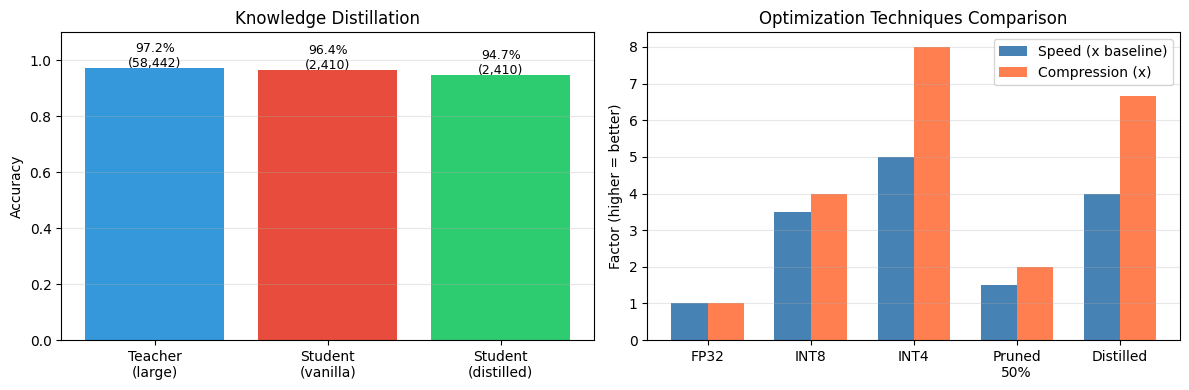

→ 圖表儲存至 plots/03_deployment_overview.png


In [6]:
print("\n" + "=" * 60)
print("5. 部署 Checklist")
print("=" * 60)

print("""
模型上線前的完整檢查清單：

  □ 模型品質
    ├ 在測試集上的指標達標
    ├ 在邊界案例上測試過
    └ 和 baseline 比較過

  □ 模型優化
    ├ 量化（INT8 或更低）
    ├ 蒸餾/剪枝（如需要更快）
    ├ TorchScript / ONNX 匯出
    └ 推論速度達標

  □ API 服務
    ├ 輸入驗證（格式、範圍）
    ├ 錯誤處理（模型出錯不 crash）
    ├ 批次推論（提高吞吐量）
    ├ 健康檢查 endpoint
    └ 日誌記錄（輸入輸出）

  □ 部署環境
    ├ Docker 容器化
    ├ 環境變數管理（不要 hardcode）
    ├ GPU / CPU 選擇
    ├ 記憶體限制設定
    └ 自動重啟（容器編排）

  □ 監控
    ├ 推論延遲 (latency)
    ├ 吞吐量 (throughput)
    ├ 錯誤率
    ├ 模型漂移 (data drift)
    └ A/B 測試

  □ 安全
    ├ API 認證 (API key / JWT)
    ├ 輸入過濾 (防止注入)
    ├ 速率限制
    └ 敏感資料處理
""")

# 結果視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 蒸餾比較
models = ['Teacher\n(large)', 'Student\n(vanilla)', 'Student\n(distilled)']
accs = [acc_teacher, acc_vanilla, acc_distilled]
params = [t_params, s_params, s_params]
colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].bar(models, accs, color=colors)
for i, (a, p) in enumerate(zip(accs, params)):
    axes[0].text(i, a + 0.005, f'{a:.1%}\n({p:,})', ha='center', fontsize=9)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Knowledge Distillation')
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# 量化/加速比較
techniques = ['FP32', 'INT8', 'INT4', 'Pruned\n50%', 'Distilled']
speed = [1.0, 3.5, 5.0, 1.5, 4.0]
sizes = [1.0, 0.25, 0.125, 0.5, 0.15]

x_pos = np.arange(len(techniques))
width = 0.35
axes[1].bar(x_pos - width/2, speed, width, label='Speed (x baseline)', color='steelblue')
axes[1].bar(x_pos + width/2, [1/s for s in sizes], width, label='Compression (x)', color='coral')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(techniques)
axes[1].set_ylabel('Factor (higher = better)')
axes[1].set_title('Optimization Techniques Comparison')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('phase-6-deployment/plots/03_deployment_overview.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/03_deployment_overview.png")

## 小結

In [7]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
部署技術總覽：

  模型壓縮：
    量化:   精度換速度和大小
    蒸餾:   用大模型教小模型
    剪枝:   刪掉不重要的權重

  部署工具：
    FastAPI:  Python API 服務
    Docker:   容器化
    ONNX:     跨框架匯出
    vLLM:     LLM 專用推論服務

  推薦的部署流程：
    1. 訓練模型 → 確認指標
    2. 量化（INT8/INT4）
    3. TorchScript 或 ONNX 匯出
    4. FastAPI 包裝
    5. Docker 容器化
    6. 部署 + 監控

═══════════════════════════════════════════════════
  Phase 6 完成！
  恭喜！你已經走完了從入門到部署的完整學習路徑。

  整個 Roadmap 回顧：
    Phase 0: 數學基礎（NumPy, 線代, 微積分, 機率）
    Phase 1: 機器學習（回歸, 分類, 聚類, 評估）
    Phase 2: 深度學習（PyTorch, NN, 訓練技巧）
    Phase 3: 訓練實務（資料處理, GPU, 實驗管理）
    Phase 4: 領域深入（CV, NLP, RL）
    Phase 5: 現代模型（Transformer, LLM, LoRA, Diffusion）
    Phase 6: 部署工程（量化, 加速, 部署）
═══════════════════════════════════════════════════
""")


小結

部署技術總覽：

  模型壓縮：
    量化:   精度換速度和大小
    蒸餾:   用大模型教小模型
    剪枝:   刪掉不重要的權重

  部署工具：
    FastAPI:  Python API 服務
    Docker:   容器化
    ONNX:     跨框架匯出
    vLLM:     LLM 專用推論服務

  推薦的部署流程：
    1. 訓練模型 → 確認指標
    2. 量化（INT8/INT4）
    3. TorchScript 或 ONNX 匯出
    4. FastAPI 包裝
    5. Docker 容器化
    6. 部署 + 監控

═══════════════════════════════════════════════════
  Phase 6 完成！
  恭喜！你已經走完了從入門到部署的完整學習路徑。

  整個 Roadmap 回顧：
    Phase 0: 數學基礎（NumPy, 線代, 微積分, 機率）
    Phase 1: 機器學習（回歸, 分類, 聚類, 評估）
    Phase 2: 深度學習（PyTorch, NN, 訓練技巧）
    Phase 3: 訓練實務（資料處理, GPU, 實驗管理）
    Phase 4: 領域深入（CV, NLP, RL）
    Phase 5: 現代模型（Transformer, LLM, LoRA, Diffusion）
    Phase 6: 部署工程（量化, 加速, 部署）
═══════════════════════════════════════════════════

